# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:

Praca z modelem językowym HerBERT

## Cel ćwiczenia

Celem ćwiczenia jest porównanie klasycznych i nowoczesnych metod reprezentacji tekstu w zadaniach NLP dla języka polskiego. W notebooku analizowane są trzy podejścia: stemming, lematyzacja oraz embeddingi kontekstowe HerBERT. Porównanie obejmuje wpływ tych metod na rozmiar słownika, jakość reprezentacji tekstu, klasyfikację sentymentu oraz podobieństwo semantyczne recenzji.

## Wykorzystane narzędzia

- Python — implementacja analizy i eksperymentów.
- Jupyter Notebook — przygotowanie raportu, tabel, wykresów i komentarzy.
- Hugging Face `datasets` — pobranie korpusu Allegro Reviews.
- `pandas` i `numpy` — przetwarzanie danych oraz obliczenia numeryczne.
- `spaCy` z modelem `pl_core_news_sm` — lematyzacja i rozpoznawanie części mowy.
- Własna klasa `PolishStemmer` — regułowy stemming tekstu polskiego.
- `transformers` i `torch` — ładowanie modelu `allegro/herbert-base-cased` oraz generowanie embeddingów.
- `scikit-learn` — TF-IDF, regresja logistyczna, PCA, t-SNE i metryki klasyfikacji.
- `matplotlib` i `seaborn` — wizualizacja wyników.

Notebook rozwiązuje zadania 1–5 z instrukcji. Wyniki tabelaryczne, wykresy i komentarze znajdują się bezpośrednio w notebooku.


## Instalacja zależności

Jeżeli biblioteki nie są jeszcze zainstalowane, uruchom w terminalu:

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install -U pip
python -m pip install -r requirements.txt
python -m spacy download pl_core_news_sm
```


In [1]:
import os
import re
import warnings
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import spacy
import nltk

from datasets import load_dataset
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_TASK_SENTENCES = 10
N_HERBERT_SAMPLE = 200

nltk.download("stopwords", quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {device}")


/home/patryk/Projects/Studia/mgr/ai/lab9/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Urządzenie: cpu


In [2]:
print("Pobieranie Allegro Reviews...")
dataset_candidates = [
    "legacy-datasets/allegro_reviews",
    "allegro/klej-allegro-reviews",
    "allegro_reviews",
]

last_error = None
for dataset_name in dataset_candidates:
    try:
        print(f"Próba: {dataset_name}")
        dataset = load_dataset(dataset_name)
        print(f"Załadowano dataset: {dataset_name}")
        break
    except Exception as error:
        last_error = error
        print(f"Nie udało się załadować {dataset_name}: {type(error).__name__}: {error}")
else:
    raise RuntimeError("Nie udało się pobrać Allegro Reviews z żadnego znanego źródła.") from last_error

df_train = pd.DataFrame(dataset["train"])
print(dataset)
print(df_train.head(3))

df_train["sentiment"] = df_train["rating"].apply(
    lambda rating: "pozytywny" if rating >= 4 else ("negatywny" if rating <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy().reset_index(drop=True)

print(f"Liczba recenzji po usunięciu neutralnych: {len(df_bin)}")
print(df_bin["sentiment"].value_counts())


Pobieranie Allegro Reviews...
Próba: legacy-datasets/allegro_reviews


Załadowano dataset: legacy-datasets/allegro_reviews
DatasetDict({
    train: Dataset({
        features: ['text', 'rating'],
        num_rows: 9577
    })
    test: Dataset({
        features: ['text', 'rating'],
        num_rows: 1006
    })
    validation: Dataset({
        features: ['text', 'rating'],
        num_rows: 1002
    })
})
                                                text  rating
0  Jako do ceny dobra. Przyssawka mogłaby być lep...     3.0
1  Na słuchawkę czekałam spory czas a po zadzwoni...     1.0
2  Czajnik na pierwszy rzut oka wygląda ok, ale n...     1.0
Liczba recenzji po usunięciu neutralnych: 8369
sentiment
pozytywny    5567
negatywny    2802
Name: count, dtype: int64


In [3]:
try:
    POLISH_STOPWORDS = set(nltk.corpus.stopwords.words("polish"))
except Exception:
    POLISH_STOPWORDS = set()

POLISH_STOPWORDS.update({
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a",
    "jest", "jak", "ale", "po", "czy", "przez", "co", "o", "za",
    "też", "już", "tak", "ten", "ta", "te", "go", "mu", "je",
    "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej",
    "jej", "jego", "ich", "by", "bo", "więc", "tylko", "jeszcze",
    "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
})


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-ząćęłńóśźż\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_basic(text: str) -> list[str]:
    return [token for token in clean_text(text).split() if len(token) > 2]


def remove_stopwords(tokens: list[str]) -> list[str]:
    return [token for token in tokens if token not in POLISH_STOPWORDS]


class PolishStemmer:
    SUFFIXES = sorted([
        "zacja", "zacji", "ości", "owie", "ania", "enie", "ienia",
        "ami", "ach", "iem", "om", "ie", "ią", "ię",
        "ej", "ym", "im", "ów", "ę", "ą",
        "a", "i", "y", "e", "u",
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word


stemmer = PolishStemmer()


def stem_tokens(tokens: list[str]) -> list[str]:
    return [stemmer.stem(token) for token in tokens]


def stem_text(text: str) -> list[str]:
    return stem_tokens(remove_stopwords(tokenize_basic(text)))


selected_reviews = (
    df_bin.sample(N_TASK_SENTENCES, random_state=RANDOM_STATE)
    .reset_index(drop=True)
    [["text", "sentiment", "rating"]]
)
selected_reviews


,text,sentiment,rating
0,"Bardzo dobre szkło, które dzięki załączonej na...",pozytywny,5.0
1,...,pozytywny,4.0
2,chińska podróba która w ogóle nie działa. Łado...,negatywny,1.0
3,Rewelacyjne etui. W bardzo łatwy sposób można ...,pozytywny,5.0
4,Silikonowy bezbarwny case można kupić u innych...,negatywny,1.0
5,Super sprzęt nie tylko dla dzieci ;) Jak dla ...,pozytywny,5.0
6,"Myszka ładna, wygodna do internetu ok. Do powa...",negatywny,1.0
7,Powiem tak duże zaskoczenie kupiłem spodziewaj...,pozytywny,5.0
8,"NIE POLECAM NAWET GO NIE UŻYŁEM ANI RAZU, Wsad...",negatywny,1.0
9,"""Wizualnie bardzo ładna, ale na tym kończą się...",negatywny,2.0


## Zadanie 1 — Stemming dla 10 zdań z korpusu


In [4]:
task1_rows = []

for sentence_id, row in selected_reviews.iterrows():
    tokens = remove_stopwords(tokenize_basic(row["text"]))
    stems = stem_tokens(tokens)
    for token, stem in zip(tokens, stems):
        task1_rows.append({
            "zdanie_id": sentence_id + 1,
            "sentiment": row["sentiment"],
            "token_oryginalny": token,
            "stem": stem,
            "zmieniony": token != stem,
        })

df_task1_tokens = pd.DataFrame(task1_rows)
display(selected_reviews)
display(df_task1_tokens)


,text,sentiment,rating
0,"Bardzo dobre szkło, które dzięki załączonej na...",pozytywny,5.0
1,...,pozytywny,4.0
2,chińska podróba która w ogóle nie działa. Łado...,negatywny,1.0
3,Rewelacyjne etui. W bardzo łatwy sposób można ...,pozytywny,5.0
4,Silikonowy bezbarwny case można kupić u innych...,negatywny,1.0
5,Super sprzęt nie tylko dla dzieci ;) Jak dla ...,pozytywny,5.0
6,"Myszka ładna, wygodna do internetu ok. Do powa...",negatywny,1.0
7,Powiem tak duże zaskoczenie kupiłem spodziewaj...,pozytywny,5.0
8,"NIE POLECAM NAWET GO NIE UŻYŁEM ANI RAZU, Wsad...",negatywny,1.0
9,"""Wizualnie bardzo ładna, ale na tym kończą się...",negatywny,2.0


,zdanie_id,sentiment,token_oryginalny,stem,zmieniony
0,1,pozytywny,dobre,dobr,True
1,1,pozytywny,szkło,szkło,False
2,1,pozytywny,które,któr,True
3,1,pozytywny,dzięki,dzięk,True
4,1,pozytywny,załączonej,załączon,True
...,...,...,...,...,...
443,10,negatywny,jedna,jedn,True
444,10,negatywny,gwiazdka,gwiazdk,True
445,10,negatywny,powyżej,powyż,True
446,10,negatywny,minimum,minimum,False


In [5]:
same_stem = (
    df_task1_tokens.groupby("stem")["token_oryginalny"]
    .agg(lambda values: sorted(set(values)))
    .reset_index()
)
same_stem["liczba_roznych_tokenow"] = same_stem["token_oryginalny"].apply(len)
same_stem = same_stem[same_stem["liczba_roznych_tokenow"] > 1]
same_stem["powod"] = "różne tokeny sprowadzone do tego samego stemu"

short_stems = df_task1_tokens[
    (df_task1_tokens["zmieniony"]) & (df_task1_tokens["stem"].str.len() <= 3)
][["stem", "token_oryginalny"]].copy()
short_stems["token_oryginalny"] = short_stems["token_oryginalny"].apply(lambda value: [value])
short_stems["liczba_roznych_tokenow"] = 1
short_stems["powod"] = "bardzo krótki lub mało czytelny stem"

df_task1_suspicious = pd.concat(
    [
        same_stem[["stem", "token_oryginalny", "liczba_roznych_tokenow", "powod"]],
        short_stems[["stem", "token_oryginalny", "liczba_roznych_tokenow", "powod"]],
    ],
    ignore_index=True,
).drop_duplicates(subset=["stem"]).head(10)

print("Potencjalnie błędne lub zaskakujące wyniki stemmingu:")
display(df_task1_suspicious)


Potencjalnie błędne lub zaskakujące wyniki stemmingu:


,stem,token_oryginalny,liczba_roznych_tokenow,powod
0,dobr,"[dobra, dobre, dobrej]",3,różne tokeny sprowadzone do tego samego stemu
1,drewnian,"[drewnianej, drewnianą]",2,różne tokeny sprowadzone do tego samego stemu
2,ekran,"[ekran, ekranie]",2,różne tokeny sprowadzone do tego samego stemu
3,kabl,"[kable, kabli, kablu]",3,różne tokeny sprowadzone do tego samego stemu
4,kończ,"[kończy, kończą]",2,różne tokeny sprowadzone do tego samego stemu
5,któr,"[która, które, który]",3,różne tokeny sprowadzone do tego samego stemu
6,lepsz,"[lepsza, lepszą]",2,różne tokeny sprowadzone do tego samego stemu
7,minimaln,"[minimalnie, minimalną]",2,różne tokeny sprowadzone do tego samego stemu
8,myśl,"[myśle, myślę]",2,różne tokeny sprowadzone do tego samego stemu
9,nadaj,"[nadaje, nadają]",2,różne tokeny sprowadzone do tego samego stemu


In [6]:
df_bin["raw_tokens"] = df_bin["text"].apply(lambda text: remove_stopwords(tokenize_basic(text)))
df_bin["stemmed_tokens"] = df_bin["raw_tokens"].apply(stem_tokens)
df_bin["stemmed_text"] = df_bin["stemmed_tokens"].apply(lambda tokens: " ".join(tokens))

vocab_raw = set(token for tokens in df_bin["raw_tokens"] for token in tokens)
vocab_stem = set(token for tokens in df_bin["stemmed_tokens"] for token in tokens)
stem_reduction = (1 - len(vocab_stem) / len(vocab_raw)) * 100

df_vocab_task1 = pd.DataFrame({
    "wariant": ["surowy tekst", "po stemmingu"],
    "rozmiar_slownika": [len(vocab_raw), len(vocab_stem)],
})
display(df_vocab_task1)
print(f"Stemming redukuje rozmiar słownika o {stem_reduction:.2f}%.")


,wariant,rozmiar_slownika
0,surowy tekst,48161
1,po stemmingu,32521


Stemming redukuje rozmiar słownika o 32.47%.


**Komentarz do Zadania 1.** Stemming redukuje słownik mechanicznie przez odcinanie końcówek,
więc jest szybki, ale bywa lingwistycznie niedokładny. Przykłady zaskakujących wyników są
wskazane w tabeli `df_task1_suspicious`: szczególnie istotne są sytuacje, gdy różne tokeny
trafiają do tego samego stemu albo stem staje się bardzo krótki i traci czytelne znaczenie.


## Zadanie 2 — Lematyzacja spaCy dla tych samych 10 zdań


In [7]:
print("Ładowanie modelu spaCy: pl_core_news_sm")
try:
    nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])
except OSError as error:
    raise OSError(
        "Brakuje modelu spaCy. Uruchom w terminalu: python -m spacy download pl_core_news_sm"
    ) from error


def lemmatize_doc(doc) -> list[str]:
    lemmas = []
    for token in doc:
        lemma = token.lemma_.lower()
        if token.is_alpha and len(lemma) > 2 and lemma not in POLISH_STOPWORDS:
            lemmas.append(lemma)
    return lemmas


def lemmatize_text(text: str) -> list[str]:
    return lemmatize_doc(nlp(clean_text(text)))


task2_rows = []
for sentence_id, row in selected_reviews.iterrows():
    doc = nlp(clean_text(row["text"]))
    for token in doc:
        if token.is_alpha and len(token.text) > 2 and token.text.lower() not in POLISH_STOPWORDS:
            original = token.text.lower()
            task2_rows.append({
                "zdanie_id": sentence_id + 1,
                "token_oryginalny": original,
                "stem": stemmer.stem(original),
                "lemat": token.lemma_.lower(),
                "POS": token.pos_,
            })

df_task2 = pd.DataFrame(task2_rows)
display(df_task2)


Ładowanie modelu spaCy: pl_core_news_sm


,zdanie_id,token_oryginalny,stem,lemat,POS
0,1,dobre,dobr,dobry,ADJ
1,1,szkło,szkło,szkło,NOUN
2,1,które,któr,który,DET
3,1,dzięki,dzięk,dzięki,ADP
4,1,załączonej,załączon,załączyć,ADJ
...,...,...,...,...,...
443,10,jedna,jedn,jeden,ADJ
444,10,gwiazdka,gwiazdk,gwiazdka,NOUN
445,10,powyżej,powyż,powyżej,ADP
446,10,minimum,minimum,minimum,NOUN


Lematyzacja całego zbioru binarnego. To może potrwać kilka minut...
Przetworzono 1000/8369 recenzji
Przetworzono 2000/8369 recenzji
Przetworzono 3000/8369 recenzji
Przetworzono 4000/8369 recenzji
Przetworzono 5000/8369 recenzji
Przetworzono 6000/8369 recenzji
Przetworzono 7000/8369 recenzji
Przetworzono 8000/8369 recenzji


,wariant,rozmiar_slownika
0,surowy tekst,48161
1,po stemmingu,32521
2,po lematyzacji,31804


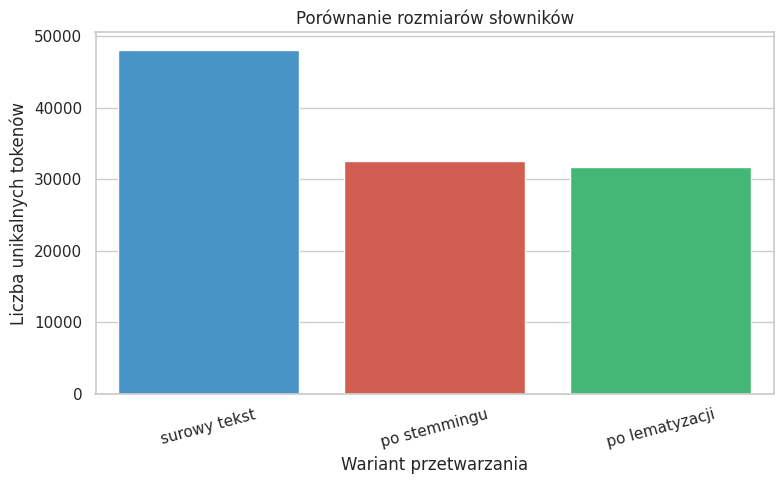

In [8]:
print("Lematyzacja całego zbioru binarnego. To może potrwać kilka minut...")
lemma_tokens_all = []
for index, doc in enumerate(nlp.pipe(df_bin["text"].map(clean_text), batch_size=128), start=1):
    lemma_tokens_all.append(lemmatize_doc(doc))
    if index % 1000 == 0:
        print(f"Przetworzono {index}/{len(df_bin)} recenzji")

df_bin["lemma_tokens"] = lemma_tokens_all
df_bin["lemma_text"] = df_bin["lemma_tokens"].apply(lambda tokens: " ".join(tokens))

vocab_lemma = set(token for tokens in df_bin["lemma_tokens"] for token in tokens)

df_vocab = pd.DataFrame({
    "wariant": ["surowy tekst", "po stemmingu", "po lematyzacji"],
    "rozmiar_slownika": [len(vocab_raw), len(vocab_stem), len(vocab_lemma)],
})
display(df_vocab)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_vocab, x="wariant", y="rozmiar_slownika", palette=["#3498db", "#e74c3c", "#2ecc71"])
plt.title("Porównanie rozmiarów słowników")
plt.xlabel("Wariant przetwarzania")
plt.ylabel("Liczba unikalnych tokenów")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [9]:
df_task2_examples = df_task2[
    (df_task2["token_oryginalny"] != df_task2["lemat"])
    & (df_task2["stem"] != df_task2["lemat"])
].copy()
df_task2_examples = df_task2_examples.sort_values(["POS", "token_oryginalny"]).head(12)
display(df_task2_examples)


,zdanie_id,token_oryginalny,stem,lemat,POS
392,10,antypoślizgowego,antypoślizgowego,antypoślizgowy,ADJ
303,8,automatyczne,automatyczn,automatyczny,ADJ
61,3,chińska,chińsk,chiński,ADJ
171,5,cienkie,cienk,cienki,ADJ
0,1,dobre,dobr,dobry,ADJ
150,4,dobrej,dobr,dobry,ADJ
175,5,dodawane,dodawan,dodawać,ADJ
289,8,drewnianej,drewnian,drewniany,ADJ
431,10,drewnianą,drewnian,drewniany,ADJ
355,9,droższego,droższego,droższy,ADJ


**Komentarz do Zadania 2.** Lematyzacja jest wyraźnie lepsza dla form fleksyjnych języka
polskiego: czasowników odmienionych przez osobę, czas i rodzaj, rzeczowników w różnych
przypadkach oraz przymiotników w liczbie i rodzaju. Stemming tylko ucina końcówki, dlatego
może tworzyć niepoprawne rdzenie. Lematyzacja korzysta z modelu językowego i POS, więc częściej
zwraca poprawną formę hasłową. Konkretne przykłady z korpusu pokazuje tabela
`df_task2_examples`.


## Zadanie 3 — Klasyfikacja sentymentu: TF-IDF i HerBERT


In [11]:
if "raw_tokens" not in df_bin.columns:
    df_bin["raw_tokens"] = df_bin["text"].apply(lambda text: remove_stopwords(tokenize_basic(text)))
if "stemmed_text" not in df_bin.columns:
    df_bin["stemmed_tokens"] = df_bin["raw_tokens"].apply(stem_tokens)
    df_bin["stemmed_text"] = df_bin["stemmed_tokens"].apply(lambda tokens: " ".join(tokens))
if "lemma_text" not in df_bin.columns:
    print("Brakuje kolumn lematyzacji, więc obliczam je teraz...")
    df_bin["lemma_tokens"] = [lemmatize_doc(doc) for doc in nlp.pipe(df_bin["text"].map(clean_text), batch_size=128)]
    df_bin["lemma_text"] = df_bin["lemma_tokens"].apply(lambda tokens: " ".join(tokens))

labels = (df_bin["sentiment"] == "pozytywny").astype(int).values

classical_variants = [
    ("Surowy tekst", df_bin["text"].tolist()),
    ("Stemming", df_bin["stemmed_text"].tolist()),
    ("Lematyzacja", df_bin["lemma_text"].tolist()),
]

results = {}
reports = {}

for method_name, texts in classical_variants:
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=labels,
    )

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[method_name] = accuracy
    reports[method_name] = classification_report(
        y_test,
        y_pred,
        target_names=["Negatywny", "Pozytywny"],
        zero_division=0,
    )

    print("=" * 70)
    print(f"Metoda: {method_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(reports[method_name])


Metoda: Surowy tekst
Accuracy: 0.8793
              precision    recall  f1-score   support

   Negatywny       0.90      0.72      0.80       560
   Pozytywny       0.87      0.96      0.91      1114

    accuracy                           0.88      1674
   macro avg       0.88      0.84      0.86      1674
weighted avg       0.88      0.88      0.88      1674

Metoda: Stemming
Accuracy: 0.8560
              precision    recall  f1-score   support

   Negatywny       0.88      0.66      0.75       560
   Pozytywny       0.85      0.95      0.90      1114

    accuracy                           0.86      1674
   macro avg       0.86      0.81      0.83      1674
weighted avg       0.86      0.86      0.85      1674

Metoda: Lematyzacja
Accuracy: 0.8554
              precision    recall  f1-score   support

   Negatywny       0.87      0.67      0.76       560
   Pozytywny       0.85      0.95      0.90      1114

    accuracy                           0.86      1674
   macro avg       

In [12]:
MODEL_NAME = "allegro/herbert-base-cased"
HERBERT_CACHE = Path("herbert_embeddings_200.npy")
HERBERT_SAMPLE_CACHE = Path("herbert_sample_200.csv")

if HERBERT_SAMPLE_CACHE.exists() and HERBERT_CACHE.exists():
    print("Wczytuję zapisane embeddingi HerBERT z cache.")
    df_herbert_sample = pd.read_csv(HERBERT_SAMPLE_CACHE)
    embeddings_herbert = np.load(HERBERT_CACHE)
else:
    pos_sample = df_bin[df_bin["sentiment"] == "pozytywny"].sample(
        N_HERBERT_SAMPLE // 2,
        random_state=RANDOM_STATE,
    )
    neg_sample = df_bin[df_bin["sentiment"] == "negatywny"].sample(
        N_HERBERT_SAMPLE // 2,
        random_state=RANDOM_STATE,
    )
    df_herbert_sample = (
        pd.concat([pos_sample, neg_sample])
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

    print(f"Ładowanie modelu: {MODEL_NAME}")
    tokenizer_herbert = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_herbert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    model_herbert.eval()


    def encode_herbert(texts: list[str]) -> np.ndarray:
        batch_size = 8 if device == "cuda" else 2
        max_length = 256 if device == "cuda" else 128
        vectors = []

        print(f"Generuję embeddingi: batch_size={batch_size}, max_length={max_length}, device={device}")
        if device == "cpu":
            print("CPU będzie wolne. Nie przerywaj komórki; wynik zapisze się do cache.")

        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start:start + batch_size]
            encoded = tokenizer_herbert(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=True,
            )
            encoded = {key: value.to(device) for key, value in encoded.items()}

            with torch.inference_mode():
                output = model_herbert(**encoded)

            hidden = output.last_hidden_state
            mask = encoded["attention_mask"].unsqueeze(-1).float()
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            vectors.append(pooled.cpu().numpy())

            print(f"Embeddingi: {min(start + batch_size, len(texts))}/{len(texts)}")

        return np.vstack(vectors)


    embeddings_herbert = encode_herbert(df_herbert_sample["text"].tolist())
    np.save(HERBERT_CACHE, embeddings_herbert)
    df_herbert_sample.to_csv(HERBERT_SAMPLE_CACHE, index=False)
    print("Zapisano cache embeddingów HerBERT.")

print(f"Kształt macierzy embeddingów: {embeddings_herbert.shape}")


Ładowanie modelu: allegro/herbert-base-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generuję embeddingi: batch_size=2, max_length=128, device=cpu
CPU będzie wolne. Nie przerywaj komórki; wynik zapisze się do cache.
Embeddingi: 2/200
Embeddingi: 4/200
Embeddingi: 6/200
Embeddingi: 8/200
Embeddingi: 10/200
Embeddingi: 12/200
Embeddingi: 14/200
Embeddingi: 16/200
Embeddingi: 18/200
Embeddingi: 20/200
Embeddingi: 22/200
Embeddingi: 24/200
Embeddingi: 26/200
Embeddingi: 28/200
Embeddingi: 30/200
Embeddingi: 32/200
Embeddingi: 34/200
Embeddingi: 36/200
Embeddingi: 38/200
Embeddingi: 40/200
Embeddingi: 42/200
Embeddingi: 44/200
Embeddingi: 46/200
Embeddingi: 48/200
Embeddingi: 50/200
Embeddingi: 52/200
Embeddingi: 54/200
Embeddingi: 56/200
Embeddingi: 58/200
Embeddingi: 60/200
Embeddingi: 62/200
Embeddingi: 64/200
Embeddingi: 66/200
Embeddingi: 68/200
Embeddingi: 70/200
Embeddingi: 72/200
Embeddingi: 74/200
Embeddingi: 76/200
Embeddingi: 78/200
Embeddingi: 80/200
Embeddingi: 82/200
Embeddingi: 84/200
Embeddingi: 86/200
Embeddingi: 88/200
Embeddingi: 90/200
Embeddingi: 92/200

Metoda: HerBERT embeddingi
Accuracy: 0.8500
              precision    recall  f1-score   support

   Negatywny       0.85      0.85      0.85        20
   Pozytywny       0.85      0.85      0.85        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



,metoda,accuracy
0,Surowy tekst,0.879331
1,Stemming,0.856033
2,Lematyzacja,0.855436
3,HerBERT embeddingi,0.850000


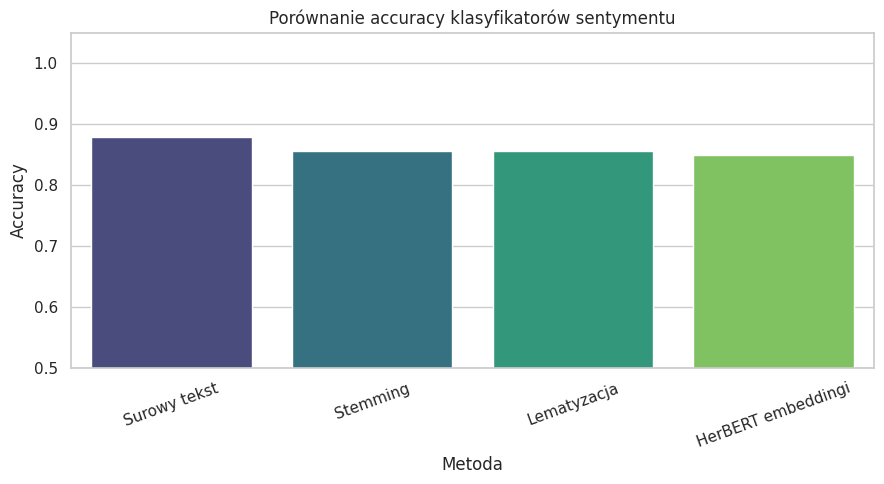

**Automatyczny komentarz do Zadania 3.** Najlepszy wynik osiąga `Surowy tekst` z accuracy `0.8793`. Różnica między stemmingiem i lematyzacją wynosi `0.0006` punktu accuracy. Przy takiej interpretacji różnica jest niewielka praktycznie.

In [13]:
labels_herbert = (df_herbert_sample["sentiment"] == "pozytywny").astype(int).values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    embeddings_herbert,
    labels_herbert,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_herbert,
)

clf_herbert = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_herbert.fit(X_train_e, y_train_e)
y_pred_e = clf_herbert.predict(X_test_e)

acc_herbert = accuracy_score(y_test_e, y_pred_e)
results["HerBERT embeddingi"] = acc_herbert

print("=" * 70)
print("Metoda: HerBERT embeddingi")
print(f"Accuracy: {acc_herbert:.4f}")
print(classification_report(y_test_e, y_pred_e, target_names=["Negatywny", "Pozytywny"], zero_division=0))

df_results = pd.DataFrame(
    [{"metoda": method, "accuracy": accuracy} for method, accuracy in results.items()]
).sort_values("accuracy", ascending=False)
display(df_results)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_results, x="metoda", y="accuracy", palette="viridis")
plt.ylim(0.5, 1.05)
plt.title("Porównanie accuracy klasyfikatorów sentymentu")
plt.xlabel("Metoda")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_method = df_results.iloc[0]["metoda"]
best_accuracy = df_results.iloc[0]["accuracy"]
stem_acc = results["Stemming"]
lemma_acc = results["Lematyzacja"]
diff = abs(stem_acc - lemma_acc)

display(Markdown(
    f"**Automatyczny komentarz do Zadania 3.** Najlepszy wynik osiąga `{best_method}` "
    f"z accuracy `{best_accuracy:.4f}`. Różnica między stemmingiem i lematyzacją wynosi "
    f"`{diff:.4f}` punktu accuracy. Przy takiej interpretacji różnica jest "
    f"{'raczej istotna praktycznie' if diff >= 0.01 else 'niewielka praktycznie'}."
))


**Komentarz do Zadania 3.** Najlepsza metoda to wariant z najwyższym `accuracy` w tabeli
`df_results`. TF-IDF na surowym tekście lub lematyzacji często jest bardzo mocnym baseline'em,
bo wykorzystuje częste słowa i n-gramy charakterystyczne dla sentymentu. HerBERT ma przewagę
semantyczną, ale tutaj jest trenowany klasyfikator tylko na 200 embeddingach, więc wynik może
być niższy niż dla klasycznych metod trenowanych na pełnym zbiorze.


## Zadanie 4 — PCA i t-SNE dla embeddingów HerBERT


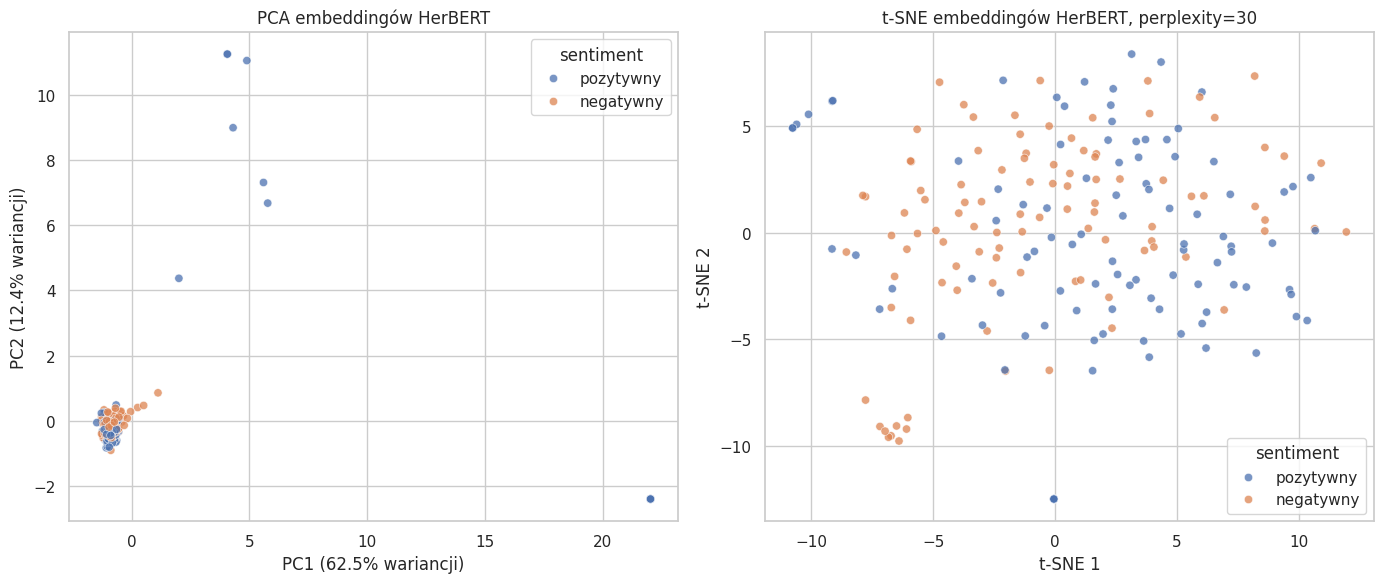

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pca = pca.fit_transform(embeddings_herbert)

perplexity = min(30, max(5, (len(df_herbert_sample) - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)
coords_tsne = tsne.fit_transform(embeddings_herbert)

df_viz = df_herbert_sample[["sentiment", "rating", "text"]].copy()
df_viz["pca_x"] = coords_pca[:, 0]
df_viz["pca_y"] = coords_pca[:, 1]
df_viz["tsne_x"] = coords_tsne[:, 0]
df_viz["tsne_y"] = coords_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_viz, x="pca_x", y="pca_y", hue="sentiment", ax=axes[0], alpha=0.75)
axes[0].set_title("PCA embeddingów HerBERT")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% wariancji)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% wariancji)")

sns.scatterplot(data=df_viz, x="tsne_x", y="tsne_y", hue="sentiment", ax=axes[1], alpha=0.75)
axes[1].set_title(f"t-SNE embeddingów HerBERT, perplexity={perplexity}")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


**Komentarz do Zadania 4.** PCA pokazuje kierunki największej globalnej wariancji, więc jest
deterministyczne i łatwiejsze do interpretacji, ale separacja klas może być słabsza. t-SNE
lepiej zachowuje lokalne sąsiedztwa, dlatego często wizualnie tworzy wyraźniejsze skupiska.
Nie należy jednak traktować odległości między odległymi klastrami t-SNE jako precyzyjnej miary
globalnego podobieństwa. Jeśli klasy są lepiej rozdzielone na t-SNE, oznacza to głównie, że
lokalnie embeddingi recenzji o podobnym sentymencie są bliżej siebie.


## Zadanie 5 — Cosine similarity dla 10 recenzji


,sentiment,rating,text
0,pozytywny,5.0,ODBIORNIK ADAPTER CHIP QI SVIEW SAMSUNG GALAXY S5 działa idealnie android rozpoznaje ładowanie indukcyjne pewnie dlatego że ma 3 piny ładowanie od 17% do 100% trwało 3 godziny bateria nowa pełna pojemność 3000 mah to jest dobry czas POLECAM
1,pozytywny,4.0,"""(+) dziecinnie łatwa obsługa, przyrządzanie jaj o wybranej twardości wreszcie stało się proste (+) dodatkowe tacki na warzywa i jaja sadzone w zestawie (-) Dość mało miejsca na wszystkich tackach pod plastikową kopułą - szczególnie kłopotliwe przy rozmiarze jaj powyżej """"M"""", wtedy jest problem ze zmieszczeniem więcej niż 4 szt. na wyznaczonych miejscach - kopuła przestaje się mieścić i domykać"""
2,pozytywny,5.0,"najlepsze szkło jakie miałem. Nie zgadzam się montaż jest skomplikowany. Wyciska się klej na środek telefonu, kładzie szkło, elegancko klej rozpływa się po całym ekranie, potem jedziemy z lampką UV. Oczywiście wcześniej trzeba pomyśleć i użyć dołączonych do zestawu naklejek do zaklejenia otworów (głośnika, mikrofonu, mini jacka, portu usb). Polecam pod telefon położyć zawczasu ręcznik papierowy. W ogóle to warto sobie zobaczyć filmik instruktażowy. Prosta operacja! Szkło jest zakrzywione i zakrywa o niebo więcej niż wszystkie dołączane gratisowo szkła hartowane (dołączane do etui). Warte 49 zł."
3,pozytywny,5.0,"Świetny telefon. Dźwięk z głośników głośny i wyraźny. Dźwięk ze słuchawek powala. Piękne, naturalne, nieprzekoloryzowane zdjęcia. Efekt bokeh bardzo dobry. Aplikacje działają błyskawicznie i bez lagów. Czytnik linii papilarnych działa błyskawicznie. Ściskanie telefonu (Edge Sense) jest fajną i przydatną funkcją. Przyciski głośności i zasilania też działają bardzo dobrze (wbrew obiegowej opinii). Wszystko działa tak jak trzeba. Jedyna wada, która mi przeszkadza, to brak wejścia słuchawkowego mini-jack, bez którego nie mogę podłączyć telefonu do radia w samochodzie."
4,pozytywny,5.0,"Bardzo estetyczne urządzenie. Właśnie czegoś takiego szukałem - listwa w postaci tradycyjnego urządzenia ze złączami z tyłu i włącznikiem z przodu. Jak dla mnie rozwiązanie idealne! Bardzo przydatna jest sygnalizacja poprawności fazy oraz oznaczenia fazy na gniazdach. Miłym dodatkiem jest woltomierz, aczkolwiek wolałbym aby był to wskaźnik cyfrowy, bez podświetlenia. Estetyka również by na tym zyskała. Jeśli już mowa o podświetleniu to niebieska dioda sygnalizująca włączenie urządzenia mogłaby świecić nieco słabiej... W sieci można znaleźć zdjęcia wnętrza urządzenia, które potwierdzają poprawność konstrukcji oraz dobrą jakość użytych materiałów. Wpływu na brzmienie czy jakość obrazu nie zauważyłem... ani poprawy ani co najważniejsze pogorszenia. Gorąco polecam urządzenie!"
5,negatywny,1.0,"Towar nie jest nowy. Tusz który otrzymałem jest odnowiony a nie nowy, czyli ponownie napełniony. Zaklejone taśmą izolacyjną logo Canon na obudowie. Nie było by z tym problemu ale kartridż nie działa. Reklamacja możliwa ale cała logistyka na mój koszt. Sami zastanówcie się czy warto. Mnie to wyniesie drożej niż nowy tusz."
6,negatywny,1.0,po pierwsze przy odpakowaniu towaru zamek byl zepsuty rozumiem jakbym uzytkowala jakis czas l! na nierownej drodze tez powinno byc stabilne a po drugie co to w ogole jest przy drugiej jezdzie rowerem kliknelam 2 x w ekran zeby odblokowac i przekrzywilo mi sie nie wiem jakim cudem po czym jechalam po nieroznej drodze i w koncu odpadlo przy czym dodatkowo zepsułam drogie słuchawki.beznadzieja szkoda kasy a wygladalo na prawdę na stabilne to jest okropne ! pomimo drogi jaka byla powinno trzymac!!!!!!!!!!!!
7,negatywny,2.0,"Etui zostało wysłane natychmiast po zakupie, doszło następnego dnia roboczego, niestety nie jest ono do końca zgodne z opisem, jest zbyt ciemne, co uniemożliwia podgląd chociażby godziny na telefonie z zamkniętym etui; klapka jest za duża co sprawia że zamknięte etui zasłania przedni aparat i nie jest dopasowane, z tego powodu nie ma ono kontaktu z ekranem i wszelkie funkcje opisane w ofercie są niem

,1_poz,2_poz,3_poz,4_poz,5_poz,6_neg,7_neg,8_neg,9_neg,10_neg
1_poz,1.000000,0.975125,0.977819,0.976362,0.971943,0.977719,0.963022,0.974642,0.979759,0.975012
2_poz,0.975125,1.000000,0.988976,0.982948,0.986881,0.983743,0.969267,0.986629,0.983893,0.987404
3_poz,0.977819,0.988976,1.000000,0.988402,0.988881,0.986743,0.971813,0.989174,0.989654,0.989999
4_poz,0.976362,0.982948,0.988402,1.000000,0.989489,0.981824,0.965566,0.985909,0.983659,0.986283
5_poz,0.971943,0.986881,0.988881,0.989489,1.000000,0.985386,0.966755,0.986976,0.982619,0.989036
6_neg,0.977719,0.983743,0.986743,0.981824,0.985386,1.000000,0.968977,0.985416,0.984852,0.986448
7_neg,0.963022,0.969267,0.971813,0.965566,0.966755,0.968977,1.000000,0.973336,0.974071,0.973286
8_neg,0.974642,0.986629,0.989174,0.985909,0.986976,0.985416,0.973336,1.000000,0.989089,0.989693
9_neg,0.979759,0.983893,0.989654,0.983659,0.982619,0.984852,0.974071,0.989089,1.000000,0.989271
10_neg,0.975012,0.987404,0.989999,0.986283,0.989036,0.986448,0.973286,0.989693,0.989271,1.000000


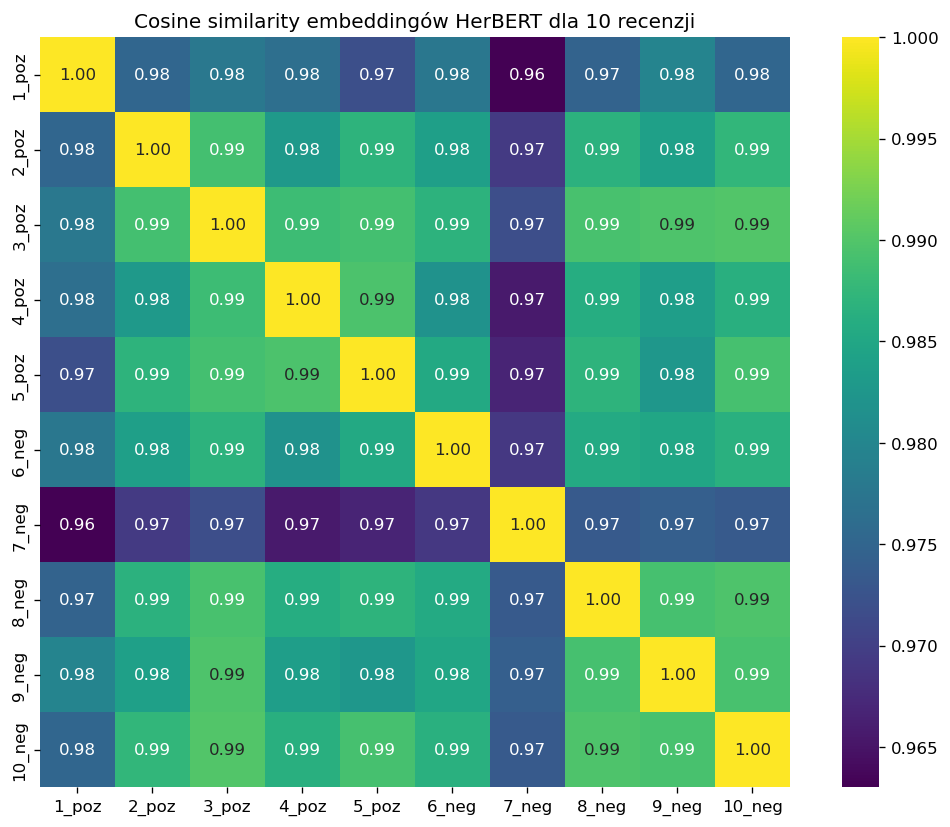

,porownanie,srednie_cosine_similarity
0,pozytywne-pozytywne,0.982683
1,negatywne-negatywne,0.981444
2,pozytywne-negatywne,0.980900


**Automatyczny komentarz do Zadania 5.** Średnie podobieństwo wewnątrz grup pozytywnych i negatywnych wynosi odpowiednio `0.983` i `0.981`, a między grupami `0.981`. Embeddingi w tej próbce grupują recenzje według sentymentu.

In [15]:
text_lengths = df_herbert_sample["text"].map(lambda value: len(clean_text(value)))
usable_reviews = df_herbert_sample[text_lengths >= 80]

pos_indices = usable_reviews[usable_reviews["sentiment"] == "pozytywny"].head(5).index.tolist()
neg_indices = usable_reviews[usable_reviews["sentiment"] == "negatywny"].head(5).index.tolist()
selected_indices = pos_indices + neg_indices

df_similarity_sample = df_herbert_sample.loc[selected_indices, ["sentiment", "rating", "text"]].reset_index(drop=True)
similarity_embeddings = embeddings_herbert[selected_indices]
similarity_matrix = cosine_similarity(similarity_embeddings)

labels_similarity = [
    f"{index + 1}_{sentiment[:3]}"
    for index, sentiment in enumerate(df_similarity_sample["sentiment"])
]

df_similarity = pd.DataFrame(similarity_matrix, index=labels_similarity, columns=labels_similarity)
display(df_similarity_sample)
display(df_similarity)

plt.figure(figsize=(9, 7))
sns.heatmap(df_similarity, cmap="viridis", annot=True, fmt=".2f", square=True)
plt.title("Cosine similarity embeddingów HerBERT dla 10 recenzji")
plt.tight_layout()
plt.show()

sentiment_array = df_similarity_sample["sentiment"].to_numpy()
pos_mask = sentiment_array == "pozytywny"
neg_mask = sentiment_array == "negatywny"


def upper_triangle_mean(matrix: np.ndarray, mask: np.ndarray) -> float:
    group_matrix = matrix[np.ix_(mask, mask)]
    upper_mask = np.triu(np.ones(group_matrix.shape, dtype=bool), k=1)
    return float(group_matrix[upper_mask].mean())


pos_pos_mean = upper_triangle_mean(similarity_matrix, pos_mask)
neg_neg_mean = upper_triangle_mean(similarity_matrix, neg_mask)
between_mean = float(similarity_matrix[np.ix_(pos_mask, neg_mask)].mean())

df_similarity_means = pd.DataFrame({
    "porownanie": ["pozytywne-pozytywne", "negatywne-negatywne", "pozytywne-negatywne"],
    "srednie_cosine_similarity": [pos_pos_mean, neg_neg_mean, between_mean],
})
display(df_similarity_means)

grouped_better = (pos_pos_mean > between_mean) and (neg_neg_mean > between_mean)
display(Markdown(
    f"**Automatyczny komentarz do Zadania 5.** Średnie podobieństwo wewnątrz grup "
    f"pozytywnych i negatywnych wynosi odpowiednio `{pos_pos_mean:.3f}` i `{neg_neg_mean:.3f}`, "
    f"a między grupami `{between_mean:.3f}`. "
    f"{'Embeddingi w tej próbce grupują recenzje według sentymentu.' if grouped_better else 'W tej próbce grupowanie według sentymentu nie jest jednoznaczne, bo co najmniej jedna średnia wewnątrz grupy nie jest większa od średniej między grupami.'}"
))


**Komentarz do Zadania 5.** Heatmapa pokazuje podobieństwo semantyczne całych recenzji,
a nie tylko podobieństwo powierzchniowych form słów. To jest informacja, której stemming
i lematyzacja nie uchwycą: dwie recenzje mogą mieć podobny sens mimo użycia innych słów
i innych konstrukcji gramatycznych. Embeddingi HerBERT kodują kontekst zdania, dlatego
cosine similarity może porównywać znaczenie recenzji na poziomie całego tekstu.
